## 1. Heuristic là gì?

Heuristic là một phương pháp giải quyết vấn đề dựa trên:
- Phỏng đoán  
- Kinh nghiệm  
- Trực giác  
- Ước lượng gần đúng  

Mục tiêu của heuristic không nhất thiết là tìm nghiệm tối ưu tuyệt đối, mà là tìm một nghiệm gần tốt nhất trong thời gian ngắn, đặc biệt hữu ích khi không thể hoặc rất khó duyệt hết toàn bộ không gian trạng thái.

## 2. Hàm heuristic là gì?

**Hàm heuristic** (ký hiệu thường là `h(x)`) là một hàm gán cho mỗi trạng thái (hoặc mỗi lựa chọn) một giá trị ước lượng thể hiện “mức độ tốt/xấu” của trạng thái đó đối với mục tiêu.

- Đầu vào: một trạng thái hiện tại (ví dụ: một đỉnh trên đồ thị, một cấu hình bàn cờ, vị trí robot, v.v.).
- Đầu ra: một số thực biểu diễn chi phí ước lượng (hoặc khoảng cách ước lượng) từ trạng thái đó đến trạng thái đích.
- Dựa trên giá trị của `h(x)`, ta chọn hành động/đường đi có triển vọng nhất để mở rộng tiếp.

Ví dụ:
- Trong bài toán tìm đường đi trên bản đồ thực, `h(x)` có thể là khoảng cách đường thẳng từ vị trí hiện tại đến đích.



## 3. A* là gì?

**A\*** là một giải thuật tìm kiếm trên đồ thị dùng để tìm đường đi từ một đỉnh bắt đầu đến một đỉnh đích, có sử dụng hàm heuristic để ước lượng chi phí còn lại.

Ý tưởng chính:
- Từ trạng thái hiện tại, A\* sinh ra tất cả các trạng thái có thể đi tiếp.
- Với mỗi trạng thái, A\* dùng hàm heuristic `h(x)` để ước lượng chi phí từ đó đến đích.
- A\* kết hợp chi phí đã đi** và chi phí ước lượng còn lại để chọn đường đi có triển vọng tốt nhất.

Nếu hàm heuristic không đánh giá quá cao chi phí thật sự còn lại (tức là admissible), A\* sẽ luôn tìm được đường đi ngắn nhất (tối ưu) nếu đường đi đó tồn tại.


## 4. Các khái niệm quan trọng trong A\*

- Open: tập các trạng thái (đỉnh) đã được sinh ra nhưng chưa xét, còn có thể mở rộng tiếp.

- Close: tập các trạng thái đã được xét xong, không cần mở rộng lại.

- Cost(p, q): chi phí (khoảng cách, thời gian, trọng số, …) để đi trực tiếp từ đỉnh `p` đến đỉnh `q`.

- g(p): chi phí tốt nhất hiện biết để đi từ trạng thái bắt đầu `s` đến trạng thái hiện tại `p`.

- h(p): chi phí ước lượng từ trạng thái hiện tại `p` đến trạng thái đích.

- f(p): tổng chi phí được dùng để ưu tiên chọn trạng thái:
  
 $$
  f(p) = g(p) + h(p)
 $$

Trong đó:
- `g(p)` càng nhỏ → đường đi đã đi qua hiện tại càng rẻ.
- `h(p)` càng nhỏ → ước lượng còn lại càng rẻ.
- A\* sẽ luôn chọn trạng thái trong `Open` có f(p) nhỏ nhất để xét trước.

## 5. Thuật toán A\* (mã giả)

Giả sử:
- `s` là trạng thái bắt đầu.
- `goal` là trạng thái đích.

```pseudo
Open  = {s}
Close = ∅

g(s) = 0
f(s) = g(s) + h(s)
prev(s) = null

while Open ≠ ∅:
    p = đỉnh trong Open có giá trị f(p) nhỏ nhất
    loại p khỏi Open

    nếu p là trạng thái đích (goal):
        -> Dừng và truy vết lại đường đi từ goal về s bằng mảng prev
        (tức là đã tìm được đường đi tốt nhất)
    
    đưa p vào Close

    // Xét tất cả các trạng thái kề (láng giềng) của p
    for mỗi đỉnh q kề với p:
        tentative_g = g(p) + Cost(p, q)

        nếu q nằm trong Close và tentative_g ≥ g(q):
            // Đã có đường tốt hơn đến q trước đó, bỏ qua
            continue

        nếu q không nằm trong Open hoặc tentative_g < g(q):
            prev(q) = p
            g(q) = tentative_g
            f(q) = g(q) + h(q)

            nếu q không nằm trong Open:
                thêm q vào Open

// Nếu vòng while kết thúc mà không gặp goal
// -> Không tồn tại đường đi từ s đến goal

# Ví dụ

Mô phỏng trên đồ thị

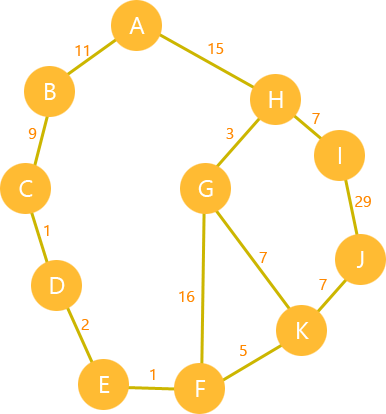

## A* cho đồ thị đã cho

1. Thông tin bài toán

- Đỉnh bắt đầu: **A**  
- Đỉnh đích: **K**

Các cạnh và trọng số

- A–B: 11  
- B–C: 9  
- C–D: 1  
- D–E: 2  
- E–F: 1  
- F–K: 5  
- F–G: 16  
- G–H: 3  
- G–K: 7  
- H–A: 15  
- H–I: 7  
- I–J: 29  
- J–K: 7  

Heuristic h(n) (ước lượng từ n đến K):

| Đỉnh | h(n) |
|------|------|
| A    | 60   |
| B    | 53   |
| C    | 36   |
| D    | 35   |
| E    | 35   |
| F    | 19   |
| G    | 16   |
| H    | 38   |
| I    | 23   |
| J    | 0    |
| K    | 7    |

Trong đó:

- `g(n)`: chi phí từ **A** đến đỉnh `n`.
- `f(n) = g(n) + h(n)`.

Ký hiệu trong bảng:  
`A60` nghĩa là `f(A) = 60`, `B64` nghĩa là `f(B) = 64`, …

2. Các bước của A*

Khởi tạo

- `g(A) = 0`  
- `f(A) = g(A) + h(A) = 0 + 60 = 60`

| Bước | Đỉnh P được chọn | Các đỉnh kề của P | Open (danh sách f)        | Close |
|------|------------------|-------------------|---------------------------|-------|
| 0    | –                | –                 | A60                       | ∅     |

Bước 1 – Mở rộng A

- P = **A**  
- Các đỉnh kề: **B**, **H**

Tính:
- g(B) = 0 + 11 = 11 → f(B) = 11 + 53 = **64**  
- g(H) = 0 + 15 = 15 → f(H) = 15 + 38 = **53**

| Bước | Đỉnh P được chọn | Các đỉnh kề của P | Open (sau khi mở rộng P) | Close |
|------|------------------|-------------------|---------------------------|-------|
| 1    | A                | B, H              | H53, B64                  | A     |

Bước 2 – Mở rộng H

- P = **H** (vì H53 là nhỏ nhất trong Open)  
- Các đỉnh kề: **A**, **G**, **I**

Tính:
- g(G) = g(H) + 3 = 15 + 3 = 18 → f(G) = 18 + 16 = **34**  
- g(I) = g(H) + 7 = 15 + 7 = 22 → f(I) = 22 + 23 = **45**  
- Đường đi mới đến A có g = 30 > 0 nên bỏ qua.

| Bước | Đỉnh P được chọn | Các đỉnh kề của P | Open (sau khi mở rộng P) | Close   |
|------|------------------|-------------------|---------------------------|---------|
| 2    | H                | A, G, I           | G34, I45, B64             | A, H    |

Bước 3 – Mở rộng G

- P = **G** (f = 34 nhỏ nhất)  
- Các đỉnh kề: **H**, **K**, **F**

Tính:
- g(K) = g(G) + 7 = 18 + 7 = 25 → f(K) = 25 + 7 = **32**  
- g(F) = g(G) + 16 = 18 + 16 = 34 → f(F) = 34 + 19 = **53**  
- Đường đi mới đến H có g = 21 > 15 nên bỏ qua.

| Bước | Đỉnh P được chọn | Các đỉnh kề của P | Open (sau khi mở rộng P)       | Close     |
|------|------------------|-------------------|---------------------------------|-----------|
| 3    | G                | H, K, F           | K32, I45, F53, B64              | A, H, G   |

Bước 4 – Chọn K và dừng

- P = **K** (f = 32 nhỏ nhất trong Open)  
- K chính là đỉnh đích, nên thuật toán dừng tại đây, không cần mở rộng thêm.

| Bước | Đỉnh P được chọn | Các đỉnh kề của P     | Open (tại thời điểm dừng) | Close     |
|------|------------------|-----------------------|---------------------------|-----------|
| 4    | K (đỉnh đích)    | – (đạt đích, dừng lại) | I45, F53, B64             | A, H, G   |


3. Đường đi tìm được

Truy vết lại theo `prev` ta được đường đi tối ưu:

$$
A \rightarrow H \rightarrow G \rightarrow K
$$

Tổng chi phí:

- A → H: 15  
- H → G: 3  
- G → K: 7  

$$
g(K) = 15 + 3 + 7 = 25
$$

Kết luận: đường đi ngắn nhất từ A đến K theo A* là:  
A → H → G → K với tổng chi phí 25.



In [ ]:
from math import inf
graph = {
    "A": {"B": 11, "H": 15},
    "B": {"A": 11, "C": 9},
    "C": {"B": 9, "D": 1},
    "D": {"C": 1, "E": 2},
    "E": {"D": 2, "F": 1},
    "F": {"E": 1, "K": 5, "G": 16},
    "G": {"H": 3, "K": 7, "F": 16},
    "H": {"A": 15, "G": 3, "I": 7},
    "I": {"H": 7, "J": 29},
    "J": {"I": 29, "K": 7},
    "K": {"F": 5, "G": 7, "J": 7},
}

h = {
    "A": 60,
    "B": 53,
    "C": 36,
    "D": 35,
    "E": 35,
    "F": 19,
    "G": 16,
    "H": 38,
    "I": 23,
    "J": 0,
    "K": 7,
}


def reconstruct_path(prev, start, goal):
    """Truy vết đường đi từ start đến goal."""
    path = [goal]
    cur = goal
    while cur != start:
        cur = prev[cur]
        path.append(cur)
    path.reverse()
    return path


def astar(start, goal):
    # Open: node -> f(node)
    open_set = {start: h[start]}
    # Close: chỉ cần lưu tên node
    closed_set = set()

    # g(n): chi phí từ start đến n
    g = {node: inf for node in graph}
    g[start] = 0

    # prev(n): đỉnh cha trên đường đi tốt nhất hiện tại
    prev = {}

    step = 0
    print(f"{'Bước':<5} {'P':<5} {'Các đỉnh kề của P':<20} {'Open':<30} {'Close'}")
    # trạng thái ban đầu
    def format_open(open_dict):
        return ", ".join(f"{n}{open_dict[n]}" for n in open_dict)

    print(f"{step:<5} {'-':<5} {'-':<20} {format_open(open_set):<30} {','.join(closed_set)}")

    while open_set:
        # chọn node trong Open có f nhỏ nhất
        current = min(open_set, key=open_set.get)
        f_current = open_set[current]

        # nếu là đỉnh đích thì dừng
        if current == goal:
            step += 1
            print(f"{step:<5} {current:<5} {'(đỉnh đích)':<20} {format_open(open_set):<30} {','.join(closed_set)}")
            path = reconstruct_path(prev, start, goal) if current != start else [start]
            return path, g[current]

        # remove current khỏi Open, đưa vào Close
        del open_set[current]
        closed_set.add(current)

        neighbors = list(graph[current].keys())

        # cập nhật bảng
        step += 1
        print(
            f"{step:<5} {current:<5} {', '.join(neighbors):<20} "
            f"{format_open(open_set):<30} {', '.join(sorted(closed_set))}"
        )

        # duyệt các đỉnh kề
        for nb, cost in graph[current].items():
            tentative_g = g[current] + cost

            # nếu nb đã trong Close và đường mới không tốt hơn thì bỏ qua
            if nb in closed_set and tentative_g >= g[nb]:
                continue

            # nếu nb chưa trong Open hoặc đường mới tốt hơn
            if nb not in open_set or tentative_g < g[nb]:
                prev[nb] = current
                g[nb] = tentative_g
                open_set[nb] = g[nb] + h[nb]

    # nếu không tìm được đường
    return None, inf


if __name__ == "__main__":
    start = "A"
    goal = "K"
    path, cost = astar(start, goal)
    if path is None:
        print("Không tồn tại đường đi.")
    else:
        print("\nĐường đi tìm được:", " -> ".join(path))
        print("Tổng chi phí:", cost)

Bước  P     Các đỉnh kề của P    Open                           Close
0     -     -                    A60                            
1     A     B, H                                                A
2     H     A, G, I              B64                            A, H
3     G     H, K, F              B64, I45                       A, G, H
4     K     (đỉnh đích)          B64, I45, K32, F53             A,H,G

Đường đi tìm được: A -> H -> G -> K
Tổng chi phí: 25


## Bài tập 1

### Đồ thị

Các đỉnh: **A, B, C, D, E, F, G**  
Đỉnh bắt đầu: **A**  
Đỉnh đích: **G**

**Các cạnh (vô hướng, có trọng số):**

- A–B: 2  
- A–C: 5  
- B–D: 4  
- B–E: 11  
- C–D: 2  
- C–F: 3  
- D–G: 6  
- E–G: 3  
- F–G: 4  

**Heuristic h(n)** (ước lượng từ n đến G):

| Đỉnh | h(n) |
|------|------|
| A    | 10   |
| B    | 8    |
| C    | 6    |
| D    | 4    |
| E    | 3    |
| F    | 2    |
| G    | 0    |

Nhớ rằng:

- `g(n)`: chi phí từ **A** đến n  
- `f(n) = g(n) + h(n)`

### A* từng bước (đúng)

Giá trị f hiển thị trong Open: `TênĐỉnh f(Đỉnh)`.
Sắp xếp theo f tăng dần.

| Bước | P (đỉnh được chọn)      | Các đỉnh kề của P    | Open (danh sách f)           | Close              |
|------|-------------------------|----------------------|------------------------------|--------------------|
| 0    | -                       | -                    | A10                          |                    |
| 1    | A                       | B, C                 | B10, C11                     | A                  |
| 2    | B                       | A, D, E              | D10, C11, E16                | A, B               |
| 3    | D                       | B, C, G              | C11, G12, E16                | A, B, D            |
| 4    | C                       | A, D, F              | F10, G12, E16                | A, B, D, C         |
| 5    | F                       | C, G                 | G12, E16                     | A, B, D, C, F      |
| 6    | G (đỉnh đích)           | C, F (không mở rộng) | G12, E16                     | A, B, D, C, F      |

Thuật toán dừng ở bước 6 khi chọn G.

### Đường đi tối ưu

Một đường đi tối ưu tìm được:

$$A \rightarrow B \rightarrow D \rightarrow G$$

Tổng chi phí:
- A→B: 2  
- B→D: 4  
- D→G: 6  

$$g(G) = 2 + 4 + 6 = 12$$

Đường đi khác cũng có cùng chi phí tối ưu (cùng g = 12):

$$A \rightarrow C \rightarrow F \rightarrow G$$

Do đó chi phí tối ưu từ A đến G là 12.

---

## Bài tập 2

### Đồ thị

Các đỉnh: **A, B, C, D, E, F, G, H**  
Đỉnh bắt đầu: **A**  
Đỉnh đích: **H**

**Các cạnh (vô hướng, có trọng số):**

- A–B: 4  
- A–C: 3  
- B–D: 5  
- B–E: 12  
- C–D: 2  
- C–F: 10  
- D–G: 4  
- E–H: 3  
- F–H: 6  
- G–H: 5  

**Heuristic h(n)** (ước lượng từ n đến H):

| Đỉnh | h(n) |
|------|------|
| A    | 13   |
| B    | 10   |
| C    | 9    |
| D    | 6    |
| E    | 2    |
| F    | 4    |
| G    | 3    |
| H    | 0    |

### A* từng bước (đúng)

| Bước | P (đỉnh được chọn)      | Các đỉnh kề của P      | Open (danh sách f)       | Close          |
|------|-------------------------|------------------------|--------------------------|----------------|
| 0    | -                       | -                      | A13                      |                |
| 1    | A                       | B, C                   | C12, B14                 | A              |
| 2    | C                       | A, D, F                | D11, B14, F17            | A, C           |
| 3    | D                       | B, G, C                | G12, B14, F17            | A, C, D        |
| 4    | G                       | H, D                   | H14, B14, F17            | A, C, D, G     |
| 5    | B                       | A, D, E                | H14, F17, E18            | A, C, D, G, B  |
| 6    | H (đỉnh đích)           | G, F (không mở rộng)   | H14, F17, E18            | A, C, D, G, B  |


### Đường đi tối ưu

Đường đi tối ưu được tìm thấy:

$$A \rightarrow C \rightarrow D \rightarrow G \rightarrow H$$

Tổng chi phí:
- A→C: 3  
- C→D: 2  
- D→G: 4  
- G→H: 5  

$$g(H) = 3 + 2 + 4 + 5 = 14$$

Không có đường đi chi phí thấp hơn, nên chi phí tối ưu từ A đến H là 14.


In [2]:
# Bài tập 1
from math import inf
graph = {
    "A": {"B": 2, "C": 5},
    "B": {"A": 2, "D": 4, "E": 11},
    "C": {"A": 5, "D": 2, "F": 3},
    "D": {"B": 4, "C": 2, "G": 6},
    "E": {"B": 11, "G": 3},
    "F": {"C": 3, "G": 4},
    "G": {"D": 6, "E": 3, "F": 4},
}

h = {
    "A": 10,
    "B": 8,
    "C": 6,
    "D": 4,
    "E": 3,
    "F": 2,
    "G": 0,
}


def reconstruct_path(prev, start, goal):
    """Truy vết đường đi từ start đến goal."""
    path = [goal]
    cur = goal
    while cur != start:
        cur = prev[cur]
        path.append(cur)
    path.reverse()
    return path


def astar(start, goal):
    # Open: node -> f(node)
    open_set = {start: h[start]}
    # Close: chỉ cần lưu tên node
    closed_set = set()

    # g(n): chi phí từ start đến n
    g = {node: inf for node in graph}
    g[start] = 0

    # prev(n): đỉnh cha trên đường đi tốt nhất hiện tại
    prev = {}

    step = 0
    print(f"{'Bước':<5} {'P':<5} {'Các đỉnh kề của P':<20} {'Open':<30} {'Close'}")
    # trạng thái ban đầu
    def format_open(open_dict):
        return ", ".join(f"{n}{open_dict[n]}" for n in open_dict)

    print(f"{step:<5} {'-':<5} {'-':<20} {format_open(open_set):<30} {','.join(closed_set)}")

    while open_set:
        # chọn node trong Open có f nhỏ nhất
        current = min(open_set, key=open_set.get)
        f_current = open_set[current]

        # nếu là đỉnh đích thì dừng
        if current == goal:
            step += 1
            print(f"{step:<5} {current:<5} {'(đỉnh đích)':<20} {format_open(open_set):<30} {','.join(closed_set)}")
            path = reconstruct_path(prev, start, goal) if current != start else [start]
            return path, g[current]

        # remove current khỏi Open, đưa vào Close
        del open_set[current]
        closed_set.add(current)

        neighbors = list(graph[current].keys())

        # cập nhật bảng
        step += 1
        print(
            f"{step:<5} {current:<5} {', '.join(neighbors):<20} "
            f"{format_open(open_set):<30} {', '.join(sorted(closed_set))}"
        )

        # duyệt các đỉnh kề
        for nb, cost in graph[current].items():
            tentative_g = g[current] + cost

            # nếu nb đã trong Close và đường mới không tốt hơn thì bỏ qua
            if nb in closed_set and tentative_g >= g[nb]:
                continue

            # nếu nb chưa trong Open hoặc đường mới tốt hơn
            if nb not in open_set or tentative_g < g[nb]:
                prev[nb] = current
                g[nb] = tentative_g
                open_set[nb] = g[nb] + h[nb]

    # nếu không tìm được đường
    return None, inf


if __name__ == "__main__":
    start = "A"
    goal = "G"
    path, cost = astar(start, goal)
    if path is None:
        print("Không tồn tại đường đi.")
    else:
        print("\nĐường đi tìm được:", " -> ".join(path))
        print("Tổng chi phí:", cost)

Bước  P     Các đỉnh kề của P    Open                           Close
0     -     -                    A10                            
1     A     B, C                                                A
2     B     A, D, E              C11                            A, B
3     D     B, C, G              C11, E16                       A, B, D
4     C     A, D, F              E16, G12                       A, B, C, D
5     F     C, G                 E16, G12                       A, B, C, D, F
6     G     (đỉnh đích)          E16, G12                       F,A,D,C,B

Đường đi tìm được: A -> B -> D -> G
Tổng chi phí: 12


In [3]:
# Bài tập 2
from math import inf
graph = {
    "A": {"B": 4, "C": 3},
    "B": {"A": 4, "D": 5, "E": 12},
    "C": {"A": 3, "D": 2, "F": 10},
    "D": {"B": 5, "C": 2, "G": 4},
    "E": {"B": 12, "H": 3},
    "F": {"C": 10, "H": 6},
    "G": {"D": 4, "H": 5},
    "H": {"E": 3, "F": 6, "G": 5},
}

h = {
    "A": 13,
    "B": 10,
    "C": 9,
    "D": 6,
    "E": 2,
    "F": 4,
    "G": 3,
    "H": 0,
}


def reconstruct_path(prev, start, goal):
    """Truy vết đường đi từ start đến goal."""
    path = [goal]
    cur = goal
    while cur != start:
        cur = prev[cur]
        path.append(cur)
    path.reverse()
    return path


def astar(start, goal):
    # Open: node -> f(node)
    open_set = {start: h[start]}
    # Close: chỉ cần lưu tên node
    closed_set = set()

    # g(n): chi phí từ start đến n
    g = {node: inf for node in graph}
    g[start] = 0

    # prev(n): đỉnh cha trên đường đi tốt nhất hiện tại
    prev = {}

    step = 0
    print(f"{'Bước':<5} {'P':<5} {'Các đỉnh kề của P':<20} {'Open':<30} {'Close'}")
    # trạng thái ban đầu
    def format_open(open_dict):
        return ", ".join(f"{n}{open_dict[n]}" for n in open_dict)

    print(f"{step:<5} {'-':<5} {'-':<20} {format_open(open_set):<30} {','.join(closed_set)}")

    while open_set:
        # chọn node trong Open có f nhỏ nhất
        current = min(open_set, key=open_set.get)
        f_current = open_set[current]

        # nếu là đỉnh đích thì dừng
        if current == goal:
            step += 1
            print(f"{step:<5} {current:<5} {'(đỉnh đích)':<20} {format_open(open_set):<30} {','.join(closed_set)}")
            path = reconstruct_path(prev, start, goal) if current != start else [start]
            return path, g[current]

        # remove current khỏi Open, đưa vào Close
        del open_set[current]
        closed_set.add(current)

        neighbors = list(graph[current].keys())

        # cập nhật bảng
        step += 1
        print(
            f"{step:<5} {current:<5} {', '.join(neighbors):<20} "
            f"{format_open(open_set):<30} {', '.join(sorted(closed_set))}"
        )

        # duyệt các đỉnh kề
        for nb, cost in graph[current].items():
            tentative_g = g[current] + cost

            # nếu nb đã trong Close và đường mới không tốt hơn thì bỏ qua
            if nb in closed_set and tentative_g >= g[nb]:
                continue

            # nếu nb chưa trong Open hoặc đường mới tốt hơn
            if nb not in open_set or tentative_g < g[nb]:
                prev[nb] = current
                g[nb] = tentative_g
                open_set[nb] = g[nb] + h[nb]

    # nếu không tìm được đường
    return None, inf


if __name__ == "__main__":
    start = "A"
    goal = "H"
    path, cost = astar(start, goal)
    if path is None:
        print("Không tồn tại đường đi.")
    else:
        print("\nĐường đi tìm được:", " -> ".join(path))
        print("Tổng chi phí:", cost)

Bước  P     Các đỉnh kề của P    Open                           Close
0     -     -                    A13                            
1     A     B, C                                                A
2     C     A, D, F              B14                            A, C
3     D     B, C, G              B14, F17                       A, C, D
4     G     D, H                 B14, F17                       A, C, D, G
5     B     A, D, E              F17, H14                       A, B, C, D, G
6     H     (đỉnh đích)          F17, H14, E18                  A,D,C,G,B

Đường đi tìm được: A -> C -> D -> G -> H
Tổng chi phí: 14
